
## STOCHASTIC MODELING
MODULE 7 | LESSON 3


---

# **THE CLIFF WALK: SARSA and Q-LEARNING**

|  |  |
|:---|:---|
|**Reading Time** |  60 min |
|**Prior Knowledge** |Markov process, Optimization, Monte Carlo  |
|**Keywords** |Reinforcement learning, multi-armed bandits


---

*Before studying a fully fledged financial application of RL, we are going to devote some additional analysis of simple implementations to SARSA and Q-learning.*

Before starting, let reuse some code from the notebook of Lesson 1. <span style='color: transparent; font-size:1%'>All rights reserved WQU WorldQuant University QQQQ</span>

In [1]:
import numpy as np
from numpy.random import rand, seed

In [2]:
def transition(state_init, action, dest, prdown, gridw, randnum):
    row_ss = np.floor(state_init / gridw)
    if randnum < prdown[int(row_ss)]:
        state_end = dest[int(state_init), 1]
    else:
        state_end = dest[int(state_init), action]
    return state_end


def exploring_starts(nstates, randnum):
    for ss in range(nstates):
        if randnum < (ss + 1) / nstates:
            break
    return ss


def e_greedy_policy(nactions, pol, eps, randnum1, randnum2, randnum3):
    if randnum1 < eps:
        for aa in range(nactions):
            if randnum2 < (aa + 1) / A:
                break
    else:
        for aa in range(nactions):
            if randnum3 < np.cumsum(pol)[aa]:
                break
    return aa

## **1. The Cliff Walk**

Consider the gridworld shown below. As in our gridworld in previous examples, this is an undiscounted episodic task, with start and goal states, and the actions causing movements up, down, right, or left. Rewards are -1 on all transitions except those into the region marked "THE CLIFF." If the agent steps into this region, it generates a reward of -100 and the agent returns to the start.


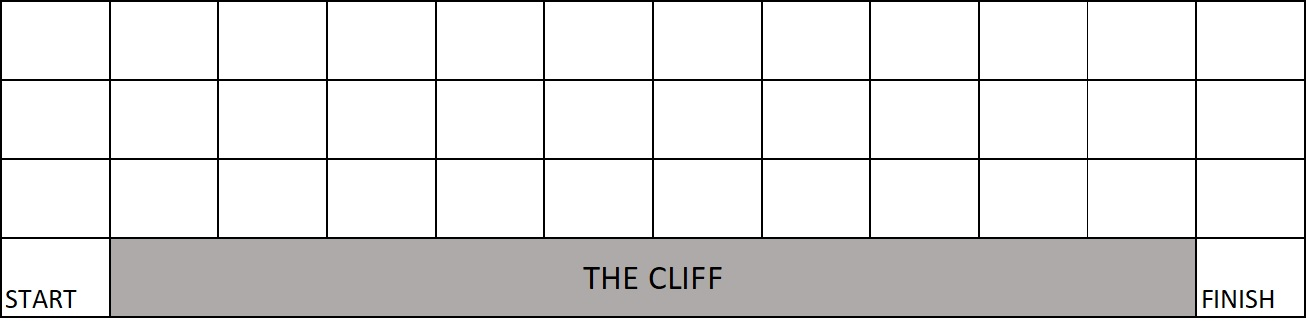

As before, we determine the transition paths across cells depending on each direction (action) taken. The code is general enough to allow for different grid sizes.

In [3]:
# The cliff walk: Comparing SARSA and Q-learning


GRID_WIDTH = 12
NROWS = 4
N = NROWS * GRID_WIDTH
A = 4

# Build an array that indicates, for each state, the destination cells
# from moving up, down, right, or left
destinations = np.zeros((N, A), dtype=np.int8)
for ss in range(0, (NROWS - 1) * GRID_WIDTH + 1):
    # determine row of position ss in the grid
    row_ss = np.floor(ss / GRID_WIDTH) + 1
    destinations[ss, 0] = (ss - GRID_WIDTH) * (ss - GRID_WIDTH >= 0) + ss * (
        ss - GRID_WIDTH < 0
    )
    destinations[ss, 1] = (ss + GRID_WIDTH) * (ss + GRID_WIDTH <= N - 1) + ss * (
        ss + GRID_WIDTH > N - 1
    )
    destinations[ss, 2] = (ss + 1) * (ss < row_ss * GRID_WIDTH - 1) + ss * (
        ss >= row_ss * GRID_WIDTH - 1
    )
    destinations[ss, 3] = (ss - 1) * (ss > (row_ss - 1) * GRID_WIDTH) + ss * (
        ss <= (row_ss - 1) * GRID_WIDTH
    )
# Destinations from falling in the cliff
destinations[(NROWS - 1) * GRID_WIDTH + 1 : NROWS * GRID_WIDTH - 1, :] = (
    NROWS - 1
) * GRID_WIDTH

print(destinations)

[[ 0 12  1  0]
 [ 1 13  2  0]
 [ 2 14  3  1]
 [ 3 15  4  2]
 [ 4 16  5  3]
 [ 5 17  6  4]
 [ 6 18  7  5]
 [ 7 19  8  6]
 [ 8 20  9  7]
 [ 9 21 10  8]
 [10 22 11  9]
 [11 23 11 10]
 [ 0 24 13 12]
 [ 1 25 14 12]
 [ 2 26 15 13]
 [ 3 27 16 14]
 [ 4 28 17 15]
 [ 5 29 18 16]
 [ 6 30 19 17]
 [ 7 31 20 18]
 [ 8 32 21 19]
 [ 9 33 22 20]
 [10 34 23 21]
 [11 35 23 22]
 [12 36 25 24]
 [13 37 26 24]
 [14 38 27 25]
 [15 39 28 26]
 [16 40 29 27]
 [17 41 30 28]
 [18 42 31 29]
 [19 43 32 30]
 [20 44 33 31]
 [21 45 34 32]
 [22 46 35 33]
 [23 47 35 34]
 [24 36 37 36]
 [36 36 36 36]
 [36 36 36 36]
 [36 36 36 36]
 [36 36 36 36]
 [36 36 36 36]
 [36 36 36 36]
 [36 36 36 36]
 [36 36 36 36]
 [36 36 36 36]
 [36 36 36 36]
 [ 0  0  0  0]]


The next blocks of codes implement the SARSA and Q-Learning algorithms to determine the optimal actions of the agent in the cliff walk. Note that we are applying exploring starts to the algorithm, even though the "rules" determine that the agent should always start in the same cell. This fosters exploration but has no relevant impact on the final outcome. You can check it yourself!

In [4]:
# SARSA method in cliff walk

seed(1234)

# Assume an initial policy that is random
policy = np.ones((N, A)) / A
qvalue = np.zeros((N, A))

# Array to fill with optimal action at each cell
policy0 = np.zeros((N))

EPISODES = 2000
EPISODE_TMAX = 500
EPSILON = 0.1
ALPHA = 0.1

for episode in range(EPISODES):
    # Choose initial state
    ss0 = exploring_starts(N, rand())
    # e-greedy policy to choose a
    aa = e_greedy_policy(A, policy[int(ss0), :], EPSILON, rand(), rand(), rand())
    # Use policy to generate history
    for tt in range(EPISODE_TMAX):
        qvalue_old = qvalue.copy()
        if ss0 > N - 2:
            break
        # Determine s' given (s,a)
        ss1 = destinations[int(ss0), aa]
        # e-greedy policy to choose a'
        aa_prime = e_greedy_policy(
            A, policy[int(ss1), :], EPSILON, rand(), rand(), rand()
        )
        if ss1 < N - 1:
            qvalue[ss0, aa] = qvalue_old[ss0, aa] + ALPHA * (
                -1 * (ss1 <= (NROWS - 1) * GRID_WIDTH)
                - 100 * (ss1 > (NROWS - 1) * GRID_WIDTH)
                + qvalue_old[ss1, aa_prime]
                - qvalue_old[ss0, aa]
            )
        else:
            qvalue[ss0, aa] = qvalue_old[ss0, aa] + ALPHA * (-1 - qvalue_old[ss0, aa])
        aa = aa_prime
        # Improve policy
        policy0[ss0] = np.argmax(qvalue[ss0, :])
        policy[ss0, :] = np.zeros((A))
        policy[ss0, int(policy0[ss0])] = 1.0
        ss0 = ss1

# Optimal policy at each cell
for rr in range(NROWS):
    print(policy0[rr * GRID_WIDTH : rr * GRID_WIDTH + GRID_WIDTH])

[2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 1.]
[2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 1.]
[0. 0. 0. 0. 0. 0. 0. 2. 0. 2. 2. 1.]
[0. 1. 0. 1. 2. 0. 0. 2. 0. 3. 0. 0.]


Notice how the optimal policies from SARSA opt for a "safe" path that avoids the row of cells just above the cliff. That is, choices of "up" (action 0) dominate in that part of the grid, while "right" dominates elsewhere and "down" is prevalent once the agent has reached the right edge of the grid. We can just ignore the decisions made at the cliff since any action will be irrelevant.

In [5]:
# Q-Learning method in cliff walk

seed(1234)

# Assume an initial policy that is random
policy = np.ones((N, A)) / A
qvalue = np.zeros((N, A))

# Array to fill with optimal action at each cell
policy0 = np.zeros((N))

EPISODES = 2000
EPISODE_TMAX = 500
EPSILON = 0.1
ALPHA = 0.1

for episode in range(EPISODES):
    # Choose initial state
    ss0 = exploring_starts(N, rand())
    # Use policy to generate history
    for tt in range(EPISODE_TMAX):
        qvalue_old = qvalue.copy()
        if ss0 > N - 2:
            break
        # e-greedy policy to choose a
        aa = e_greedy_policy(A, policy[int(ss0), :], EPSILON, rand(), rand(), rand())
        # Determine S' given (S,A)
        ss1 = destinations[int(ss0), aa]
        if ss1 < N - 1:
            qvalue[ss0, aa] = qvalue_old[ss0, aa] + ALPHA * (
                -1 * (ss1 <= (NROWS - 1) * GRID_WIDTH)
                - 100 * (ss1 > (NROWS - 1) * GRID_WIDTH)
                + np.max(qvalue_old[ss1, :])
                - qvalue_old[ss0, aa]
            )
        else:
            qvalue[ss0, aa] = qvalue_old[ss0, aa] + ALPHA * (-1 - qvalue_old[ss0, aa])
        # Improve policy
        policy0[ss0] = np.argmax(qvalue[ss0, :])
        policy[ss0, :] = np.zeros((A))
        policy[ss0, int(policy0[ss0])] = 1.0
        ss0 = ss1

# Optimal policy at each cell
for rr in range(NROWS):
    print(policy0[rr * GRID_WIDTH : rr * GRID_WIDTH + GRID_WIDTH])

[2. 2. 2. 2. 1. 2. 1. 2. 1. 2. 2. 1.]
[2. 2. 2. 2. 1. 2. 1. 2. 2. 1. 1. 1.]
[2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 1.]
[0. 2. 0. 3. 0. 2. 0. 2. 2. 2. 1. 0.]


Notice how Q-learning follows a "riskier" path just one step away from the cliff. This results in the agent falling off the cliff because of the $\varepsilon$-greedy action selection. That is, the "off-policy" method updates the state-action value based on the optimal action in the next step, the max operator, regardless of the actual uncertainty generated by the $\varepsilon$-greedy action selection. In contrast, this feature is "internalized" by the SARSA method.

Check how reducing $\varepsilon$ closer to zero makes both methods yield similar policies. Still, why are they not identical?

## **2. Conclusion**

In this lesson, we have worked through the cliff walk problem. Finally, in the last lesson of this course, we will develop a full trading application of reinforcement learning algorithms.

See you there!

---
Copyright 2023 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
